In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_csv('day_wise.csv')
country_df = pd.read_csv('country_wise_latest.csv')

print("Day-wise columns:", df.columns.tolist())
print("Country columns:", country_df.columns.tolist())
print(df.head(3))


Day-wise columns: ['Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases', 'Recovered / 100 Cases', 'Deaths / 100 Recovered', 'No. of countries']
Country columns: ['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases', 'Recovered / 100 Cases', 'Deaths / 100 Recovered', 'Confirmed last week', '1 week change', '1 week % increase', 'WHO Region']
         Date  Confirmed  Deaths  Recovered  Active  New cases  New deaths  \
0  2020-01-22        555      17         28     510          0           0   
1  2020-01-23        654      18         30     606         99           1   
2  2020-01-24        941      26         36     879        287           8   

   New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
0              0                3.06                   5.05   
1              2                2.75                   4.59   
2             

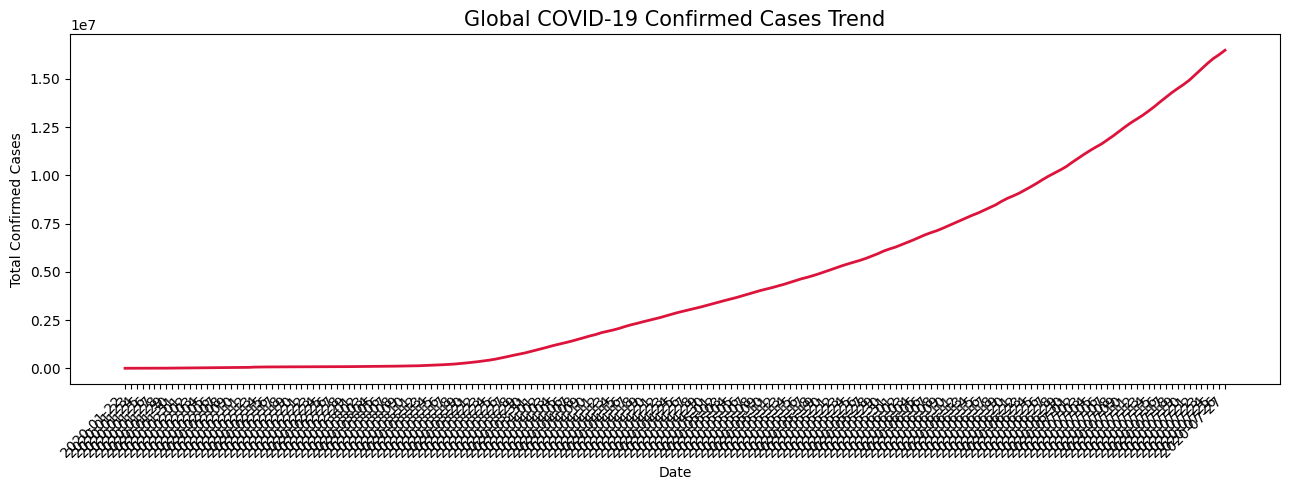

✅ Chart 1 saved


In [2]:
plt.figure(figsize=(13,5))
plt.plot(df['Date'], df['Confirmed'], color='crimson', linewidth=2)
plt.title('Global COVID-19 Confirmed Cases Trend', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Total Confirmed Cases')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('daily_trend.png', dpi=150)
plt.show()
print("✅ Chart 1 saved")

/tmp/ipykernel_10446/115513893.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='Confirmed', y='Country/Region', palette='Reds_r')


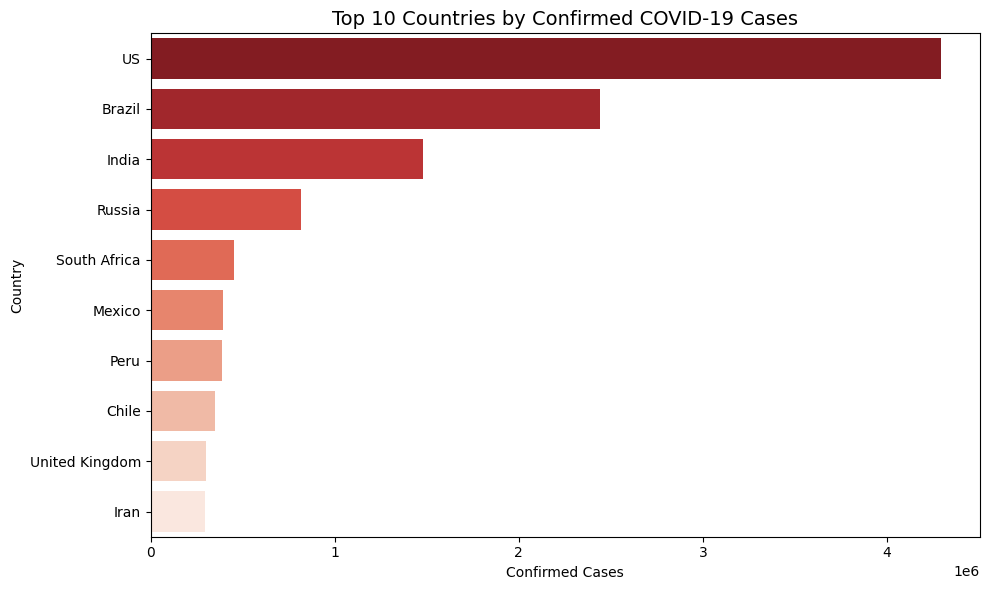

✅ Chart 2 saved


In [4]:
top10 = country_df.nlargest(10, 'Confirmed')[['Country/Region', 'Confirmed']]

plt.figure(figsize=(10,6))
sns.barplot(data=top10, x='Confirmed', y='Country/Region', palette='Reds_r')
plt.title('Top 10 Countries by Confirmed COVID-19 Cases', fontsize=14)
plt.xlabel('Confirmed Cases')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('region_comparison.png', dpi=150)
plt.show()
print("✅ Chart 2 saved")

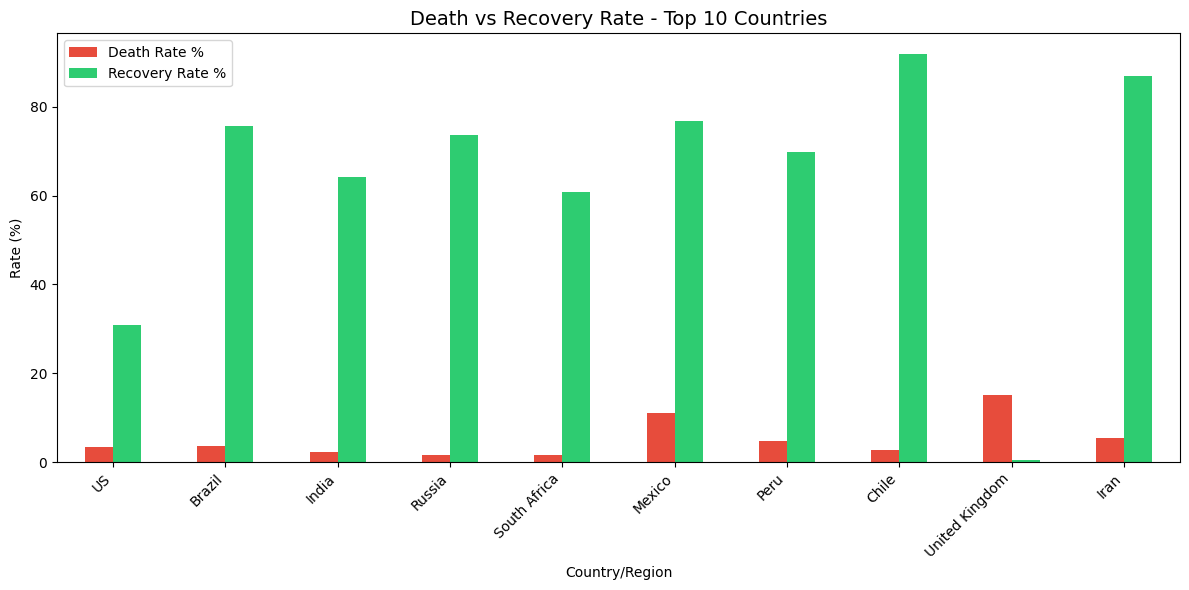

✅ Chart 3 saved


In [5]:
country_df['Death Rate %'] = (country_df['Deaths'] / country_df['Confirmed'] * 100).round(2)
country_df['Recovery Rate %'] = (country_df['Recovered'] / country_df['Confirmed'] * 100).round(2)

top10_rates = country_df.nlargest(10, 'Confirmed')[['Country/Region','Death Rate %','Recovery Rate %']]
top10_rates.set_index('Country/Region').plot(kind='bar', figsize=(12,6), color=['#e74c3c','#2ecc71'])
plt.title('Death vs Recovery Rate - Top 10 Countries', fontsize=14)
plt.ylabel('Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('death_recovery_rates.png', dpi=150)
plt.show()
print("✅ Chart 3 saved")